In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [30]:
df = pd.read_csv('E:/OneDrive/Documents/coding/MLInternship/week2/Titanic-Dataset.csv')

In [31]:
df.head()

,ivPassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
df['hascabin'] = df['Cabin'].notna().astype(int)

In [33]:
df['Age'].fillna(df['Age'].median(), inplace=True)


C:\Users\mabdu\AppData\Local\Temp\ipykernel_27756\286566303.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [34]:
df = df.drop('Name',axis =1)
df = df.drop('ivPassengerId',axis =1)

In [35]:
cabin_encoder = LabelEncoder()
df['Cabin'] = cabin_encoder.fit_transform(df['Cabin'])

In [36]:
sex_encoder = LabelEncoder()
df['Sex'] = sex_encoder.fit_transform(df['Sex'])

In [37]:
df = df.drop('Ticket',axis =1)

In [38]:
embarked_encoder = LabelEncoder()
df['Embarked'] = embarked_encoder.fit_transform(df['Embarked'])

In [39]:
df['cabin_deck'] = df['Cabin'].fillna('U').astype(str).str[0]


In [40]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Alone'] = (df['FamilySize'] == 1).astype(int)



In [41]:
# Remove outliers from numeric columns using the IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows where all numeric columns are within 1.5*IQR
# This creates a new DataFrame without outliers

df_no_outliers = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original shape: {df.shape}")
print(f"Shape after removing outliers: {df_no_outliers.shape}")

# If you want to continue working with the outlier-removed DataFrame, uncomment the next line:
df = df_no_outliers




Original shape: (891, 13)
Shape after removing outliers: (499, 13)


In [42]:
df.shape

(499, 13)

In [43]:
'''
df = df.drop('Alone', axis = 1) #since family size 1 infers that a person was alone no need for another feature reducing memory
df = df.drop('Fare', axis=1) #despite a better correlation i dont see how fare can affect chances of survival
df= df.drop('Embarked',axis =1) #doesnt matter where u board from lahore, queenstown or southampton ur chances of survival should not matter
'''

"\ndf = df.drop('Alone', axis = 1) #since family size 1 infers that a person was alone no need for another feature reducing memory\ndf = df.drop('Fare', axis=1) #despite a better correlation i dont see how fare can affect chances of survival\ndf= df.drop('Embarked',axis =1) #doesnt matter where u board from lahore, queenstown or southampton ur chances of survival should not matter\n"

In [44]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,hascabin,cabin_deck,FamilySize,Alone
0,0,3,1,22.0,1,0,7.2500,147,2,0,1,2,0
2,1,3,0,26.0,0,0,7.9250,147,2,0,1,1,1
4,0,3,1,35.0,0,0,8.0500,147,2,0,1,1,1
5,0,3,1,28.0,0,0,8.4583,147,1,0,1,1,1
9,1,2,0,14.0,1,0,30.0708,147,0,0,1,2,0


In [45]:
df = df.drop(['SibSp', 'Parch' ],axis =1)

In [46]:
df.head()


,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,hascabin,cabin_deck,FamilySize,Alone
0,0,3,1,22.0,7.2500,147,2,0,1,2,0
2,1,3,0,26.0,7.9250,147,2,0,1,1,1
4,0,3,1,35.0,8.0500,147,2,0,1,1,1
5,0,3,1,28.0,8.4583,147,1,0,1,1,1
9,1,2,0,14.0,30.0708,147,0,0,1,2,0


In [47]:
correlations = df.corr()['Survived'].sort_values(ascending=False)
print (correlations)

Survived      1.000000
Fare          0.196099
FamilySize    0.071215
Age          -0.054923
Alone        -0.090156
Pclass       -0.115688
Embarked     -0.124840
Sex          -0.543194
Cabin              NaN
hascabin           NaN
cabin_deck         NaN
Name: Survived, dtype: float64


In [48]:
x = df.drop(['Survived', 'FamilySize', 'Age', 'Alone'], axis =1)
y = df['Survived']
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print (x)

     Pclass  Sex     Fare  Cabin  Embarked  hascabin cabin_deck
0         3    1   7.2500    147         2         0          1
2         3    0   7.9250    147         2         0          1
4         3    1   8.0500    147         2         0          1
5         3    1   8.4583    147         1         0          1
9         2    0  30.0708    147         0         0          1
..      ...  ...      ...    ...       ...       ...        ...
882       3    0  10.5167    147         2         0          1
883       2    1  10.5000    147         2         0          1
884       3    1   7.0500    147         2         0          1
886       2    1  13.0000    147         2         0          1
890       3    1   7.7500    147         1         0          1

[499 rows x 7 columns]


In [49]:
pipelines = {
    'DecisionTree' : Pipeline([
        ('scalar', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=1, random_state=42))

    ]),
    'KNN': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Naive-Bayes': Pipeline([
        ('scalar', StandardScaler()),
        ('clf', GaussianNB())

        ])
}


In [50]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [51]:
k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    pipeline = Pipeline([
        ('scalar', StandardScaler()),
        ('clf', knn)
    ])
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    scores.append(score)
    print(f"K={k}: Test Accuracy = {score:.4f}")

best_k = k_range[scores.index(max(scores))]
print(f"Best K: {best_k} with accuracy {max(scores):.4f}")

K=1: Test Accuracy = 0.8100
K=2: Test Accuracy = 0.8300
K=3: Test Accuracy = 0.8500
K=4: Test Accuracy = 0.8400
K=5: Test Accuracy = 0.8700
K=6: Test Accuracy = 0.8300
K=7: Test Accuracy = 0.8300
K=8: Test Accuracy = 0.8200
K=9: Test Accuracy = 0.8200
K=10: Test Accuracy = 0.8200
K=11: Test Accuracy = 0.8600
K=12: Test Accuracy = 0.8600
K=13: Test Accuracy = 0.8600
K=14: Test Accuracy = 0.8600
K=15: Test Accuracy = 0.8600
K=16: Test Accuracy = 0.8600
K=17: Test Accuracy = 0.8500
K=18: Test Accuracy = 0.8600
K=19: Test Accuracy = 0.8500
K=20: Test Accuracy = 0.8600
Best K: 5 with accuracy 0.8700
K=15: Test Accuracy = 0.8600
K=16: Test Accuracy = 0.8600
K=17: Test Accuracy = 0.8500
K=18: Test Accuracy = 0.8600
K=19: Test Accuracy = 0.8500
K=20: Test Accuracy = 0.8600
Best K: 5 with accuracy 0.8700


In [52]:
from sklearn.model_selection import GridSearchCV

# Set up parameter grid for max_depth
param_grid = {'clf__max_depth': range(1, 21)}

dt_pipeline = Pipeline([
    ('scalar', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42))
])

grid_search = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best max_depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_dt = grid_search.best_estimator_
test_acc = best_dt.score(X_test, y_test)
print(f"Test set accuracy with best max_depth: {test_acc:.4f}")

Best max_depth: 1
Best cross-validated accuracy: 0.8322
Test set accuracy with best max_depth: 0.8200


In [53]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    print(f"{name} training accuracy: {train_score:.4f}")
    print(f"{name} testing accuracy: {test_score:.4f}")
    print("-" * 30)

DecisionTree training accuracy: 0.8321
DecisionTree testing accuracy: 0.8200
------------------------------
KNN training accuracy: 0.8571
KNN testing accuracy: 0.8700
------------------------------
Naive-Bayes training accuracy: 0.8246
Naive-Bayes testing accuracy: 0.7900
------------------------------



DecisionTree Model Evaluation


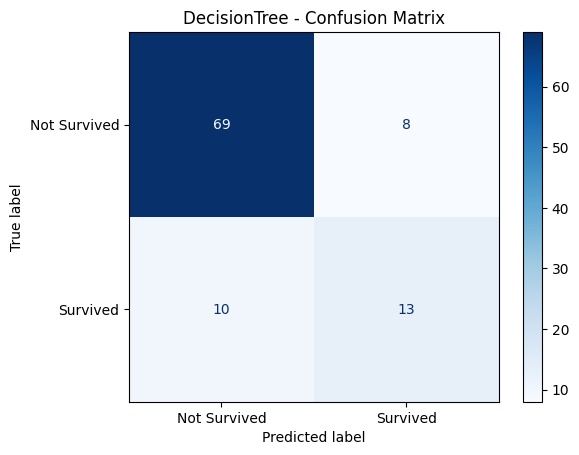

              precision    recall  f1-score   support

Not Survived       0.87      0.90      0.88        77
    Survived       0.62      0.57      0.59        23

    accuracy                           0.82       100
   macro avg       0.75      0.73      0.74       100
weighted avg       0.81      0.82      0.82       100



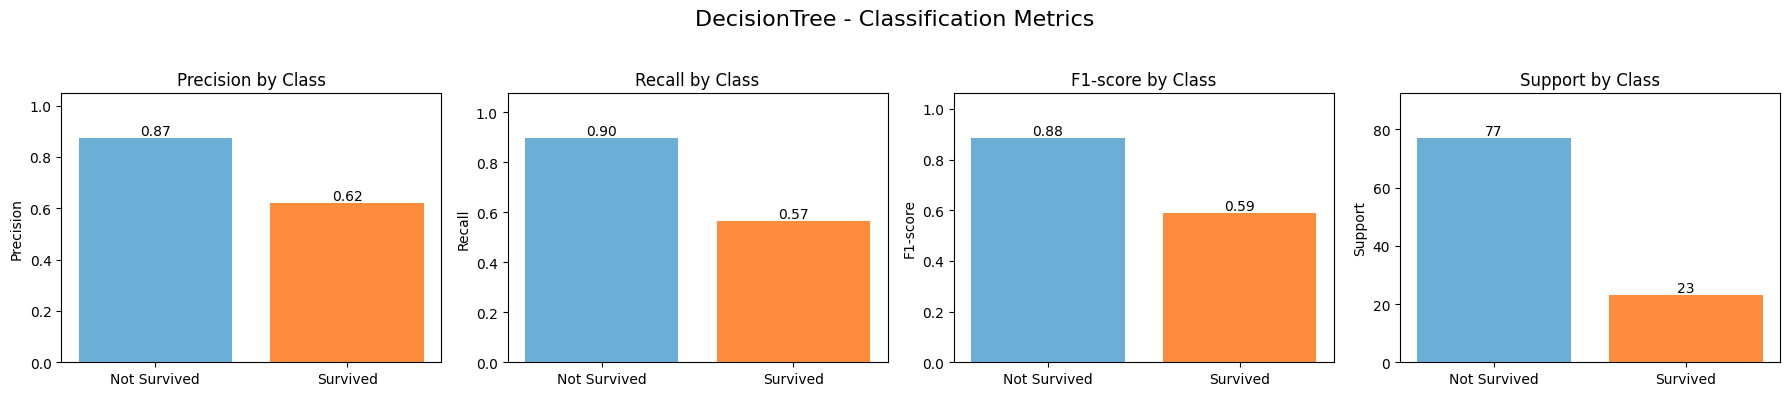


KNN Model Evaluation


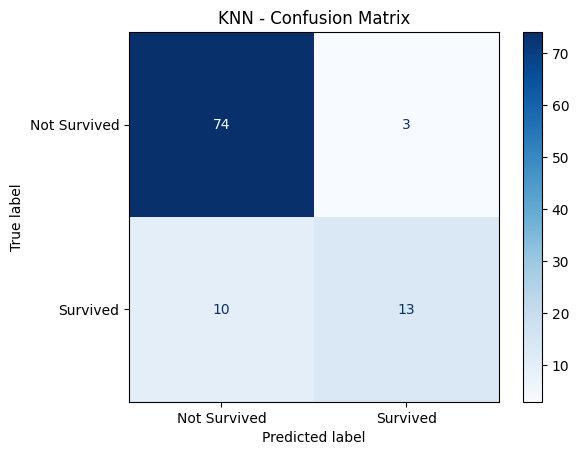

              precision    recall  f1-score   support

Not Survived       0.88      0.96      0.92        77
    Survived       0.81      0.57      0.67        23

    accuracy                           0.87       100
   macro avg       0.85      0.76      0.79       100
weighted avg       0.87      0.87      0.86       100



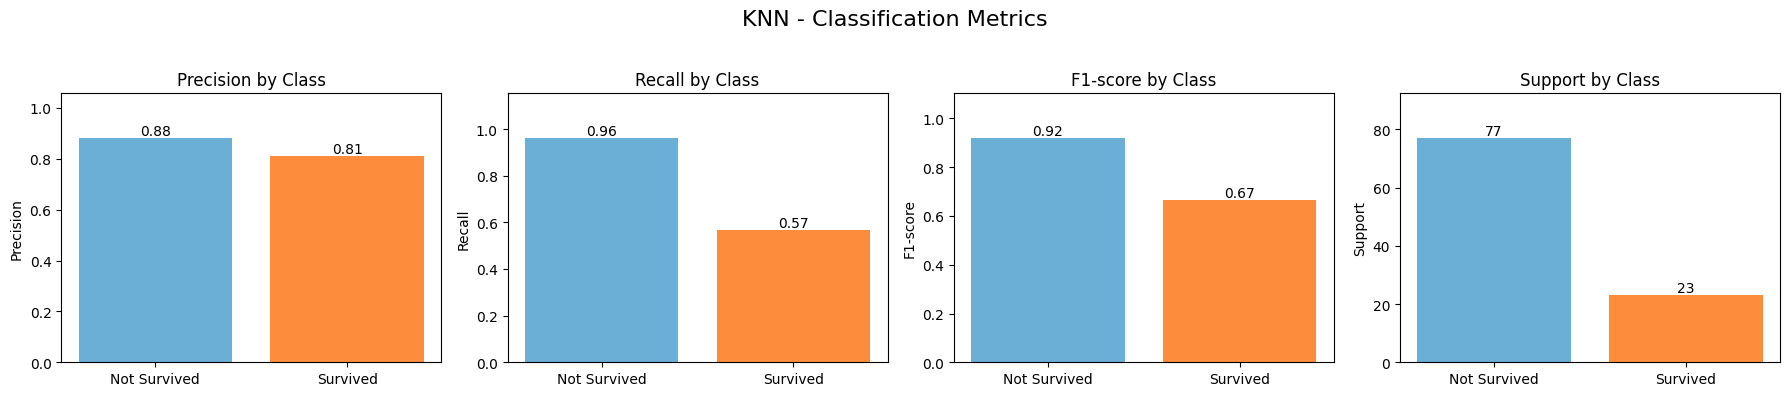


Naive-Bayes Model Evaluation


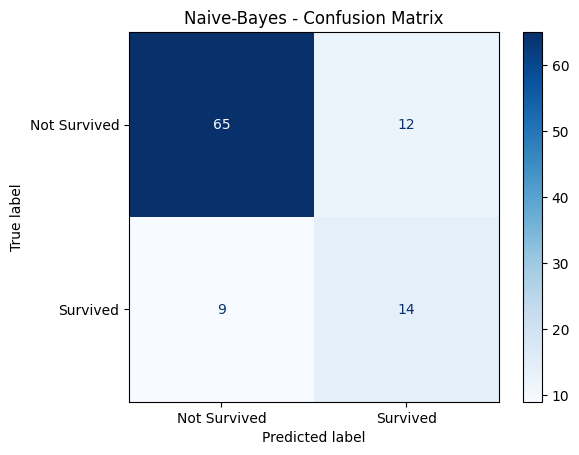

              precision    recall  f1-score   support

Not Survived       0.88      0.84      0.86        77
    Survived       0.54      0.61      0.57        23

    accuracy                           0.79       100
   macro avg       0.71      0.73      0.72       100
weighted avg       0.80      0.79      0.79       100



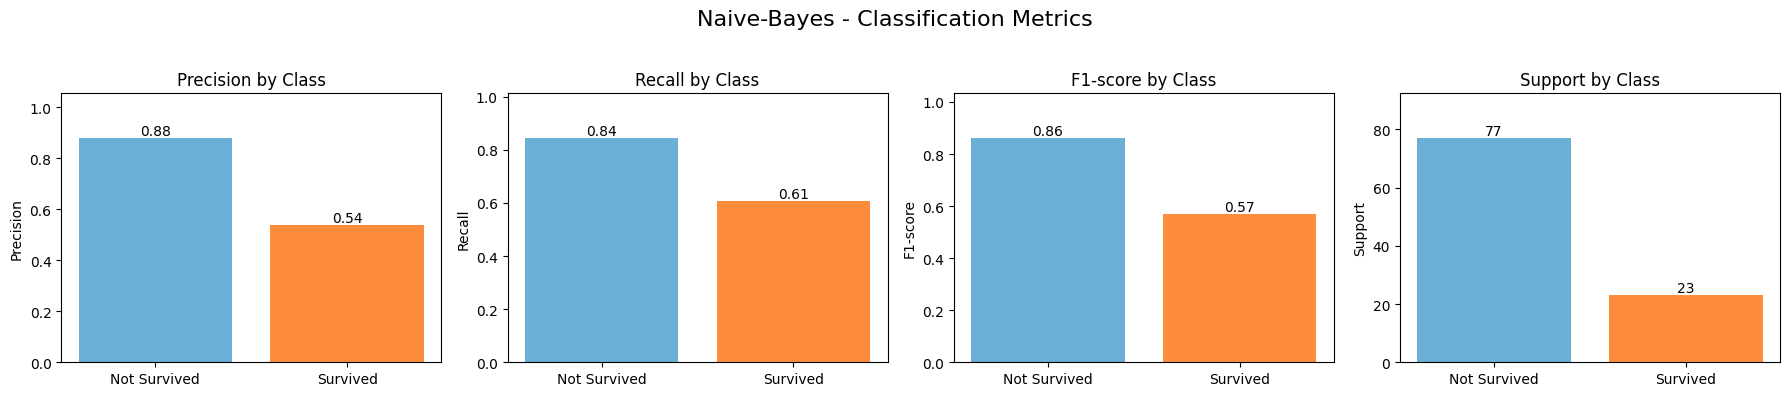

In [26]:
model_names = ['DecisionTree', 'KNN', 'Naive-Bayes']

for name in model_names:
    print(f"\n{name} Model Evaluation")
    y_pred = pipelines[name].predict(X_test)
    
    # Confusion Matrix
    disp = ConfusionMatrixDisplay.from_estimator(
        pipelines[name], X_test, y_test, cmap='Blues', display_labels=['Not Survived', 'Survived']
    )
    disp.ax_.set_title(f"{name} - Confusion Matrix")
    plt.show()
    
    # Classification Report
    report = classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived'], output_dict=True)
    print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))
    
    # Extract metrics
    metrics = ['precision', 'recall', 'f1-score', 'support']
    classes = ['Not Survived', 'Survived']
    values = {metric: [report[cls][metric] for cls in classes] for metric in metrics}
    
    # Plot metrics
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    for i, metric in enumerate(metrics):
        axs[i].bar(classes, values[metric], color=['#6baed6', '#fd8d3c'])
        axs[i].set_title(f"{metric.capitalize()} by Class")
        axs[i].set_ylabel(metric.capitalize())
        axs[i].set_ylim(0, max(values[metric]) * 1.2 if metric != 'support' else max(values[metric]) * 1.2)
        for idx, val in enumerate(values[metric]):
            axs[i].text(idx, val, f"{val:.2f}" if metric != 'support' else f"{int(val)}", ha='center', va='bottom')
    fig.suptitle(f"{name} - Classification Metrics", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

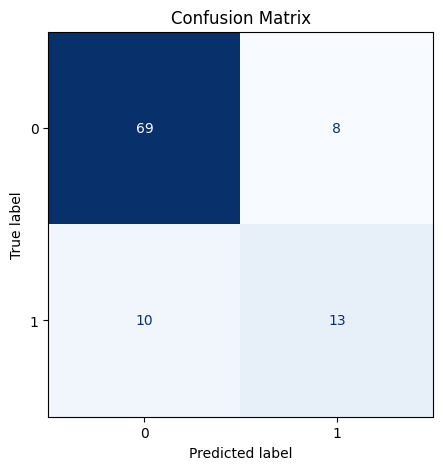

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.90      0.88        77
           1       0.62      0.57      0.59        23

    accuracy                           0.82       100
   macro avg       0.75      0.73      0.74       100
weighted avg       0.81      0.82      0.82       100



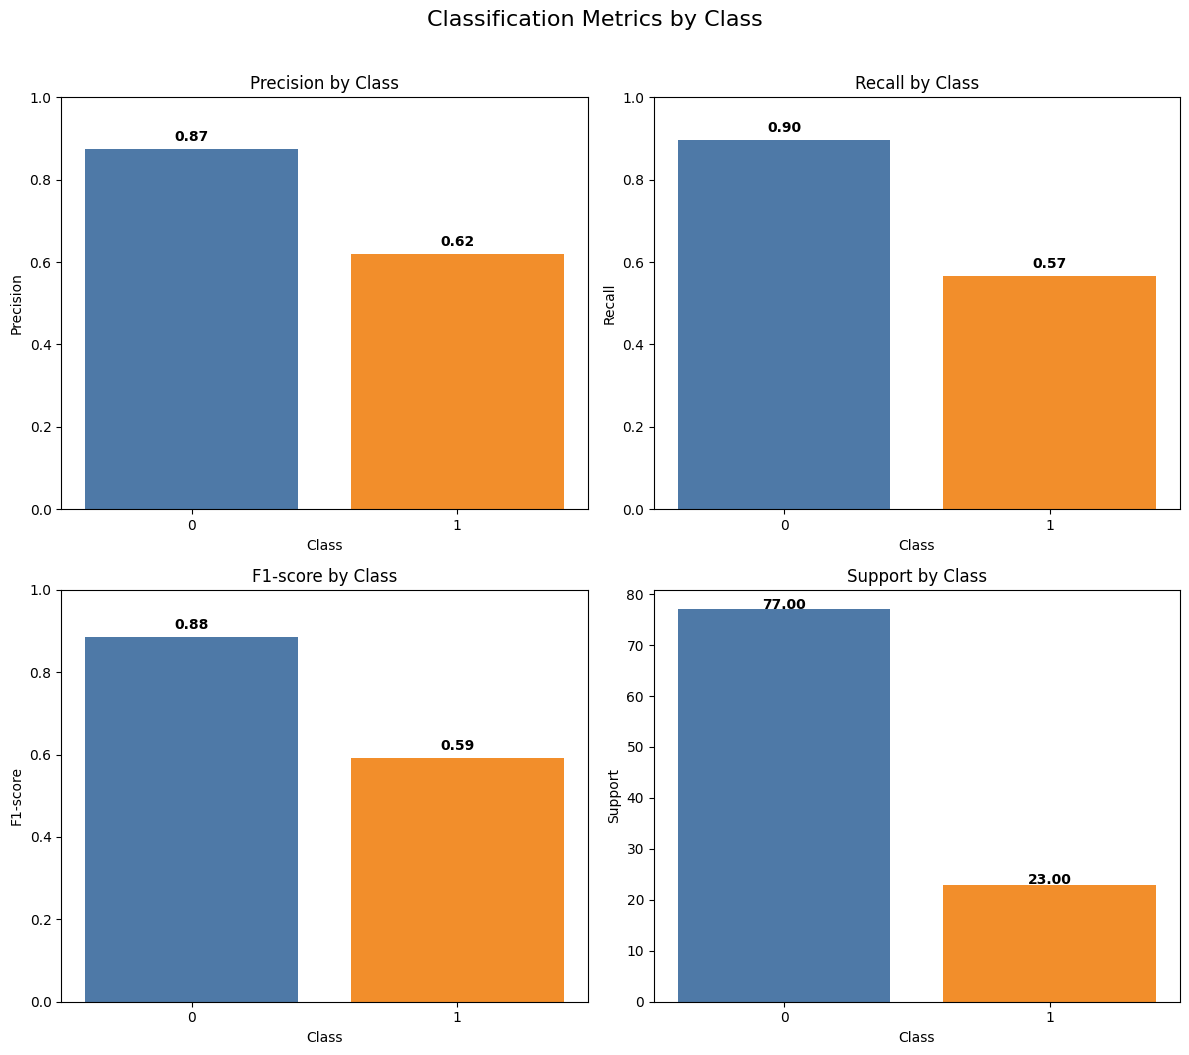

In [27]:
# Predict on the test set using the best decision tree model
y_pred = best_dt.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_dt.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Plot Precision, Recall, F1-score, and Support for each class
metrics = ['precision', 'recall', 'f1-score', 'support']
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for idx, metric in enumerate(metrics):
    values = [report[cls][metric] for cls in classes]
    axs[idx].bar(classes, values, color=['#4e79a7', '#f28e2b'])
    axs[idx].set_title(f"{metric.capitalize()} by Class")
    axs[idx].set_xlabel("Class")
    axs[idx].set_ylabel(metric.capitalize())
    if metric != 'support':
        axs[idx].set_ylim(0, 1)
    for i, v in enumerate(values):
        axs[idx].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.suptitle("Classification Metrics by Class", fontsize=16, y=1.05)
plt.show()

In [54]:
#import joblib
#joblib.dump(best_dt, "titanic_model.pkl")

In [55]:
# Save the KNN model, scaler, and encoders if KNN has the highest test accuracy
import joblib
best_model_name = None
best_model = None
best_score = 0.0
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    if test_score > best_score:
        best_score = test_score
        best_model_name = name
        best_model = pipe
print(f"Best model: {best_model_name} with test accuracy: {best_score:.4f}")
if best_model_name == 'KNN':
    joblib.dump(best_model, 'titanic_best_knn_model.joblib')
    print("KNN model saved as 'titanic_best_knn_model.joblib'")
    # Save the scaler used in the KNN pipeline
    scaler = best_model.named_steps['scalar']
    joblib.dump(scaler, 'titanic_knn_scaler.joblib')
    print("Scaler used in KNN model saved as 'titanic_knn_scaler.joblib'")
    # Save the encoders if used
    joblib.dump(sex_encoder, 'titanic_sex_encoder.joblib')
    joblib.dump(cabin_encoder, 'titanic_cabin_encoder.joblib')
    joblib.dump(embarked_encoder, 'titanic_embarked_encoder.joblib')
    print("Encoders saved as 'titanic_sex_encoder.joblib', 'titanic_cabin_encoder.joblib', and 'titanic_embarked_encoder.joblib'")

Best model: KNN with test accuracy: 0.8700
KNN model saved as 'titanic_best_knn_model.joblib'
Scaler used in KNN model saved as 'titanic_knn_scaler.joblib'
Encoders saved as 'titanic_sex_encoder.joblib', 'titanic_cabin_encoder.joblib', and 'titanic_embarked_encoder.joblib'
